# Correcting for Galactic $\gamma\gamma$ Attenuation in an Extended Source Spectrum

This tutorial demonstrates how to reconstruct the intrinsic gamma-ray spectrum of an astrophysical source by correcting for Galactic $\gamma\gamma$ absorption using the GPSP atlas framework.

As a practical example, the analysis focuses on the UHE gamma-ray emission detected by LHAASO from the direction of the Cygnus X-3 region. 

**Cao, Z., et al. 2025. https://arxiv.org/abs/2512.16638**

The tutorial covers:

- Construction of a region-averaged survival probability profile.
- Treatment of source morphology and distance uncertainties.
- Correction of measured flux points and best-fit spectral models.
- Propagation of GPSP systematic uncertainties.
- Comparison with previously published attenuation corrections.
- Investigation of potential Lorentz-Invariance Violation (LIV) effects using the GPSP-LIV atlas.

The example datasets used throughout this tutorial are available in the **Example Datasets** section of the documentation.

In [24]:
import os
import sys

# Do not forget to edit here!
sys.path.insert(0, os.path.abspath("../../../gpsp-atlas"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patheffects as path_effects
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize

from scipy.interpolate import interp1d

from astropy.table import QTable
import astropy.units as u

from gpsp_atlas_helper import GPSPAtlasHelper

In [2]:
STYLE = {
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.labelweight": "normal",
}
plt.rcParams.update(STYLE)

## Defining the Source Morphology

Although Cygnus X-3 is a point-like source for the LHAASO angular resolution of approximately $0.24^\circ$ (at 100 TeV), the GPSP atlas is constructed with an angular resolution of $0.1^\circ$.

Consequently, the source is not treated as a single spatial pixel within the atlas framework. Instead, the survival probability must be averaged over an extended source region matching to the point spread function (PSF) of the LHAASO experiment.

For this tutorial, the source morphology is approximated by a Gaussian distribution with a characteristic angular scale matching the LHAASO PSF.

The following configuration is adopted:

| Parameter | Value |
|------------|---------|
| Morphology | Extended |
| Radius ($r_{\rm out}$) | $0.24^\circ$ |
| Spatial weighting | Gaussian |
| Gaussian width | $0.24^\circ$ |
| Radial sampling | `uniform_radius` |

Using Gaussian weighting assigns larger importance to the central region of the source, reflecting the expectation that the gamma-ray emission is concentrated at the best-fit source position.

This configuration provides a realistic approximation of the effective spatial response of the measurement.

In [3]:
# Configuration & Data Loading
atlas_r12 = GPSPAtlasHelper("GPSP_Atlas_R12.fits")

# Cygnus X-3 Source position in (l,b)
l     = 79.85
b     = 0.7

# Cygnus X-3 Distance configuration
d     = 8.95
d_err = 0.96
distance_sampling='mc'
n_distance_samples=500
include_distance_uncertainty=True

# Cygnus X-3 Morphology Configuration
shape           = 'extended'
r_out           = 0.24
n_points        = 100
radial_sampling = 'uniform_radius'
weighting       = 'gaussian'
gaussian_sigma  = 0.24

# Prepare kwargs
region_kwargs = dict(l=l, b=b, d=d, d_err=d_err, shape=shape, r_out=r_out, n_points=n_points, 
                     radial_sampling=radial_sampling, weighting=weighting, gaussian_sigma=gaussian_sigma,
                     distance_sampling=distance_sampling, n_distance_samples=n_distance_samples, 
                     include_distance_uncertainty=include_distance_uncertainty, random_seed=100, return_individual=True)

# Get survival profiles for Cygnus X-3 region both from GPSP R12 and F98 Atlases
results_r12 = atlas_r12.get_region_survival_profile(**region_kwargs)

## Diagnostic Plots

Before applying attenuation corrections, it is generally useful to inspect the sampling configuration used by the GPSP helper.

The diagnostic plots below summarize three important components of the analysis:

### Spatial Sampling

Shows the sampling locations generated inside the source region together with their associated weights.

### Distance Sampling

Illustrates the Monte Carlo realizations of the source distance used to propagate distance uncertainties into the survival probability calculation.

### Survival Probability Profile

Displays the region-averaged survival probability as a function of gamma-ray energy, including the uncertainty bands arising from morphology and distance sampling.

These diagnostics provide a useful validation of the adopted source configuration before proceeding to spectral corrections.

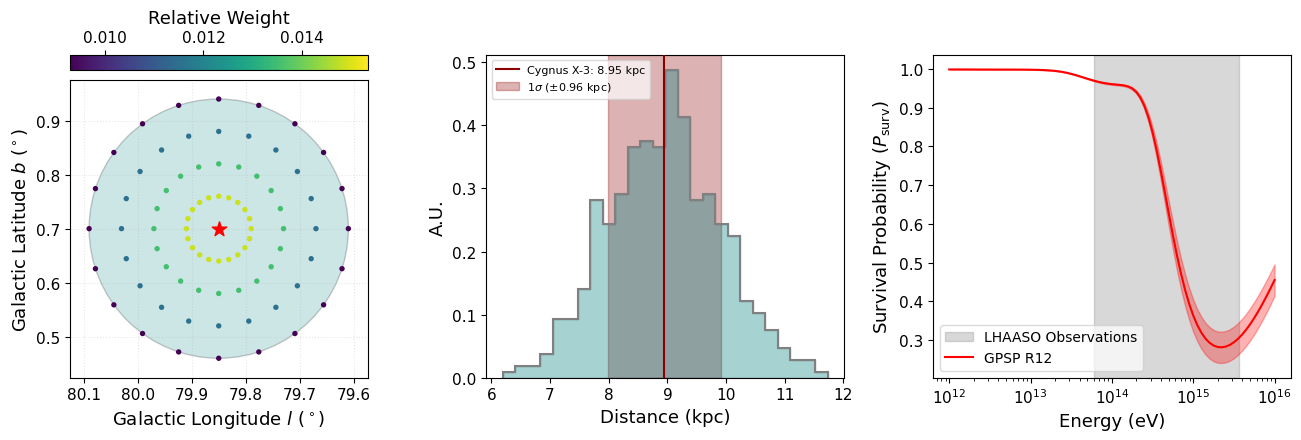

In [4]:
# Plotting (Optimized 1x3 Layout)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
ax1, ax2, ax3 = axes

# Force square on ax1
ax1.set_aspect('equal', adjustable='box')

# --- PANEL 1: Spatial Region ---
roi_circle = Circle(xy=(region_kwargs['l'], region_kwargs['b']), radius=region_kwargs['r_out'], 
                    facecolor='teal', alpha=0.2, edgecolor='black', lw=1.0, zorder=1,)

ax1.add_patch(roi_circle)

ax1.scatter(region_kwargs['l'], region_kwargs['b'], marker='*', s=120, color='red', zorder=5, label='Cygnus X-3')

ax1.set_xlabel(r"Galactic Longitude $l$ ($^\circ$)")
ax1.set_ylabel(r"Galactic Latitude $b$ ($^\circ$)")

sc = ax1.scatter(results_r12["points"][:, 0], results_r12["points"][:, 1], c=results_r12["weights"], s=15, cmap='viridis', edgecolors='none', zorder=3)

divider = make_axes_locatable(ax1)
cax = divider.append_axes("top", size="5%", pad=0.1)
cbar = plt.colorbar(sc, cax=cax, orientation="horizontal")
cax.xaxis.set_ticks_position('top')
cax.xaxis.set_label_position('top')
cbar.set_label("Relative Weight", labelpad=5)

l_cen = region_kwargs['l']
b_cen = region_kwargs['b']
lim = region_kwargs['r_out'] * 1.15

ax1.set_xlim(l_cen + lim, l_cen - lim)
ax1.set_ylim(b_cen - lim, b_cen + lim)
ax1.grid(alpha=0.3, ls=':')

# --- PANEL 2: Survival Profile ---
ax3.axvspan(60e12, 3700e12, color='gray', alpha=0.3, label='LHAASO Observations', zorder=0)
ax3.plot(results_r12["energies_ev"], results_r12["average"], color='red', lw=1.5, label='GPSP R12', zorder=3)
ax3.fill_between(results_r12["energies_ev"], results_r12["low"], results_r12["high"], color='red', alpha=0.3, zorder=3)

ax3.set_xscale("log")
ax3.set_xlabel("Energy (eV)")
ax3.set_ylabel(r"Survival Probability ($P_{\rm surv}$)")
ax3.legend(loc='lower left', frameon=True, framealpha=0.7)
#ax3.grid(alpha=0.2, which='both')

# --- PANEL 3: Distance Sampling (Optimized Style) ---
# Use stepfilled histogram to make it cleaner and look modern
ax2.hist(
    results_r12["distance_samples"], bins=26, weights=results_r12["distance_weights"], 
    density=True, histtype='stepfilled', facecolor='teal', alpha=0.35, edgecolor='black', zorder=1)
ax2.hist(
    results_r12["distance_samples"], bins=26, weights=results_r12["distance_weights"], 
    density=True, histtype='step', color='gray', lw=1.5, zorder=2
)

# Benchmark nominal distance and map the uncertainty interval
d_val = region_kwargs["d"]
d_err = region_kwargs["d_err"]
ax2.axvline(d_val, color='darkred', lw=1.5, ls='-', label=f'Cygnus X-3: {d_val} kpc', zorder=3)
ax2.axvspan(d_val - d_err, d_val + d_err, color='darkred', alpha=0.3, label=rf'1$\sigma$ ($\pm${d_err} kpc)', zorder=0)

ax2.set_xlabel("Distance (kpc)")
ax2.set_ylabel("A.U.")
ax2.legend(loc='upper left', frameon=True, framealpha=0.7, fontsize=8)
#ax2.grid(alpha=0.2, ls=':')

plt.tight_layout()

## Loading the Observational Data

The attenuation correction can be applied either to:

1. Measured flux points.
2. Best-fit spectral models.

For the Cygnus X-3 example, both data products are available.

### Flux Measurements

The measured LHAASO flux points are provided with asymmetric statistical uncertainties.

### Spectral Model

The best-fit power-law representation of the observed spectrum is provided together with its associated uncertainty band.

The example datasets used below are available in the **Example Datasets** section and can be downloaded directly from the documentation.

In [5]:
# ===========================================
# Read measured FLUX DATA (asymmetric errors)
# ===========================================
flux_data_file = "example_datasets/Cygnus_X-3_LHAASO_FluxData_Uncorrected.dat"
flux_data_table = QTable.read(flux_data_file, format="ascii.ecsv")
energy_flux = flux_data_table["e_ref"]
flux_observed_data = flux_data_table["dnde"]
flux_observed_errp = flux_data_table["dnde_errp"]
flux_observed_errn = flux_data_table["dnde_errn"]

# ===========================================================
# Read corrected (Popescu 2017) FLUX DATA (asymmetric errors)
# ===========================================================
flux_corr_P17_data_file = "example_datasets/Cygnus_X-3_LHAASO_FluxData_Corrected_Popescu2017.dat"
flux_corr_P17_data_table = QTable.read(flux_corr_P17_data_file, format="ascii.ecsv")
energy_flux_corr = flux_corr_P17_data_table["e_ref"]
flux_corr_P17_data = flux_corr_P17_data_table["dnde"]
flux_corr_P17_errp = flux_corr_P17_data_table["dnde_errp"]
flux_corr_P17_errn = flux_corr_P17_data_table["dnde_errn"]

# ===============================================
# Read observed spectrum MODEL (symmetric errors)
# ===============================================
cygnus_observed = "example_datasets/Cygnus_X-3_BestFitPL_Uncorrected.ecsv"
spec_table = QTable.read(cygnus_observed, format="ascii.ecsv")

energy_model = spec_table["e_ref"]
flux_observed_model = spec_table["dnde"]
flux_observed_model_err = spec_table["dnde_err"]

## Correcting the Measured Spectrum

The `process_spectrum_with_gpsp()` function can be used both to apply attenuation effects to intrinsic spectra and to reconstruct intrinsic spectra from observed data.

For this tutorial, the function is operated in **correction mode**:

```python
mode="correct"
```

which removes Galactic $\gamma\gamma$ attenuation from the observed spectrum.

### Error Propagation

GPSP uncertainties originate from two independent sources:

- Statistical uncertainties associated with the measurements.
- Systematic uncertainties associated with morphology and distance sampling.

The helper module can combine these contributions using either:

### Linear Combination

```python
error_comb_mode="linear"
```

which provides a conservative uncertainty estimate,

or

### Quadrature Combination

```python
error_comb_mode="quadrature"
```

which assumes statistically independent uncertainty contributions.

For this example, the quadrature approach is adopted.

### Flux Point Corrections

Since the measured LHAASO flux points contain asymmetric uncertainties, the correction is performed using:

```python
energy=energy_flux
flux=flux_observed_data
flux_errp=flux_observed_errp
flux_errn=flux_observed_errn
```

The helper automatically propagates the asymmetric uncertainties through the attenuation correction procedure.

For datasets with symmetric uncertainties, the simpler argument

```python
flux_err
```

can be used instead.

In [6]:
error_comb_mode = 'quadrature'

# ============================================================
# Correct FLUX DATA
# ============================================================
correct_flux_result = atlas_r12.process_spectrum_with_gpsp(gpsp_result=results_r12, mode="correct", energy=energy_flux, 
                                                           flux=flux_observed_data, flux_errp=flux_observed_errp, flux_errn=flux_observed_errn, 
                                                           calc_errors=True, return_table=True, error_comb_mode=error_comb_mode)

flux_corrected_data = correct_flux_result["flux"]
flux_corrected_errp = correct_flux_result["flux_errp"]
flux_corrected_errn = correct_flux_result["flux_errn"]

# ============================================================
# Correct MODEL spectrum
# ============================================================
correct_model_result = atlas_r12.process_spectrum_with_gpsp(gpsp_result=results_r12, mode="correct", energy=energy_model, 
                                                            flux=flux_observed_model, flux_err=flux_observed_model_err, calc_errors=True, 
                                                            return_table=True, error_comb_mode=error_comb_mode)

flux_corrected_model = correct_model_result["flux"]
flux_corrected_model_err = correct_model_result["flux_err"] if "flux_err" in correct_model_result else np.zeros_like(flux_corrected_model)

# ============================================================
# Convert FLUX DATA to SED
# ============================================================
sed_observed_data = (energy_flux**2 * flux_observed_data).to("TeV cm-2 s-1")
sed_observed_errp = (energy_flux**2 * flux_observed_errp).to("TeV cm-2 s-1")
sed_observed_errn = (energy_flux**2 * flux_observed_errn).to("TeV cm-2 s-1")

sed_corrected_data = (energy_flux**2 * flux_corrected_data).to("TeV cm-2 s-1")
sed_corrected_errp = (energy_flux**2 * flux_corrected_errp).to("TeV cm-2 s-1")
sed_corrected_errn = (energy_flux**2 * flux_corrected_errn).to("TeV cm-2 s-1")

sed_p17_corr_data = (energy_flux_corr**2 * flux_corr_P17_data).to("TeV cm-2 s-1")
sed_p17_corr_errp = (energy_flux_corr**2 * flux_corr_P17_errp).to("TeV cm-2 s-1")
sed_p17_corr_errn = (energy_flux_corr**2 * flux_corr_P17_errn).to("TeV cm-2 s-1")

# ============================================================
# Convert MODEL spectra to SED
# ============================================================
sed_observed_model = (energy_model**2 * flux_observed_model).to("TeV cm-2 s-1")
sed_observed_model_err = (energy_model**2 * flux_observed_model_err).to("TeV cm-2 s-1")

sed_corrected_model = (energy_model**2 * flux_corrected_model).to("TeV cm-2 s-1")
sed_model_total_low = (energy_model**2 * correct_model_result["flux_total_low"]).to("TeV cm-2 s-1")
sed_model_total_high = (energy_model**2 * correct_model_result["flux_total_high"]).to("TeV cm-2 s-1")

## Reconstructed Intrinsic Flux Points

The correction procedure produces a new set of flux points representing the inferred intrinsic gamma-ray emission before Galactic $\gamma\gamma$ attenuation.

The helper returns several useful quantities:

| Output | Description |
|----------|-------------|
| `flux` | Corrected flux values |
| `flux_errp` | Corrected upper statistical uncertainty |
| `flux_errn` | Corrected lower statistical uncertainty |
| `flux_total_low` | Lower total uncertainty envelope |
| `flux_total_high` | Upper total uncertainty envelope |
| `survival_probability` | Median survival probability |
| `survival_low` | Lower survival envelope |
| `survival_high` | Upper survival envelope |

These products can be used directly for spectral fitting, emission-model comparisons, and uncertainty propagation studies.

The figure below compares:

- The observed LHAASO flux measurements.
- The observed best-fit spectral model.
- The reconstructed intrinsic flux points.
- The reconstructed intrinsic spectral model.

The shaded regions indicate the total uncertainty envelopes obtained after combining statistical and GPSP systematic uncertainties.

The correction is performed using the GPSP R12 atlas and the source morphology and distance assumptions described previously.

It is important to note that the original LHAASO analysis adopted the Popescu et al. (2017) ISRF model to correct the measured gamma-ray fluxes.

Despite being based on a totally independent implementation and interpolation framework, the corrected flux points obtained using the GPSP R12 atlas are found to be in very good agreement with the corrected fluxes reported by the LHAASO Collaboration.

This demonstrates that the GPSP atlas framework can reliably reproduce published absorption-corrected gamma-ray measurements while simultaneously providing a flexible platform for uncertainty propagation and alternative attenuation scenarios.

/tmp/ipykernel_346662/105067146.py:30: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  leg1 = ax.legend(handles=model_lines, loc='upper left', fontsize=10, framealpha=0.8)


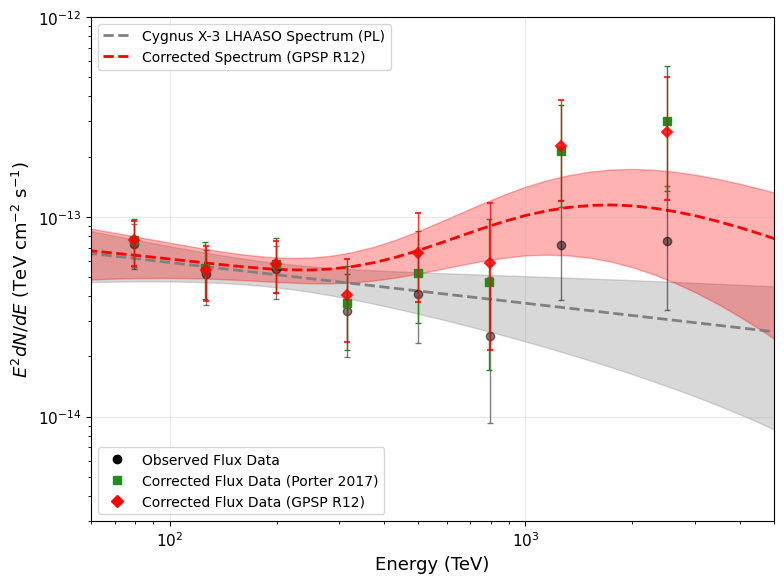

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(energy_model, sed_observed_model, lw=2, color='gray', ls='--', label='Cygnus X-3 LHAASO Spectrum (PL)')
ax.fill_between(energy_model.value, (sed_observed_model - sed_observed_model_err).value, (sed_observed_model + sed_observed_model_err).value, alpha=0.30, color='gray')

ax.plot(energy_model, sed_corrected_model, lw=2.0, ls='--', color='red', label='Corrected Spectrum (GPSP R12)')
ax.fill_between(energy_model.value, sed_model_total_low.value, sed_model_total_high.value, alpha=0.30, color='red')

ax.errorbar(energy_flux.value, sed_corrected_data.value, yerr=[sed_corrected_errn.value, sed_corrected_errp.value], fmt='D', markersize=5, 
            markerfacecolor='red', markeredgecolor='red', markeredgewidth=1.5, ecolor='red', elinewidth=1, capsize=2, linestyle='none', 
            zorder=10, label='Corrected Flux Data (GPSP R12)', alpha=0.8)

ax.errorbar(energy_flux.value, sed_observed_data.value, yerr=[sed_observed_errn.value, sed_observed_errp.value], fmt='o', markersize=6, 
            markerfacecolor='black', markeredgecolor='black', ecolor='black', elinewidth=1, capsize=2, linestyle='none', 
            zorder=8, label='Observed Flux Data (LHAASO)', alpha=0.5)

ax.errorbar(energy_flux_corr.value, sed_p17_corr_data.value, yerr=[sed_p17_corr_errn.value, sed_p17_corr_errp.value], fmt='s', markersize=6, 
            markerfacecolor='forestgreen', markeredgecolor='forestgreen', ecolor='forestgreen', elinewidth=1, capsize=2, linestyle='none', 
            zorder=9, label='Corrected Flux Data (Popescu 2017)', alpha=1.0)

ax.set_xscale("log") 
ax.set_yscale("log")
ax.set_xlabel(r"Energy (TeV)", fontsize=13) 
ax.set_ylabel(r"$E^2 dN/dE$ (TeV cm$^{-2}$ s$^{-1}$)", fontsize=13)
ax.set_xlim(60, 5000) 
ax.set_ylim(3e-15, 1e-12)
ax.grid(alpha=0.3); ax2.tick_params(which='both', direction='in', top=True, right=True, pad=8)

model_lines = ax.get_lines()[0:3] 
leg1 = ax.legend(handles=model_lines, loc='upper left', fontsize=10, framealpha=0.8)
ax.add_artist(leg1)

data_handles = [Line2D([0], [0], color='black', marker='o', linestyle='None', label='Observed Flux Data'),
                Line2D([0], [0], color='forestgreen', marker='s', linestyle='None', label='Corrected Flux Data (Porter 2017)'),
                Line2D([0], [0], color='red', marker='D', linestyle='None', label='Corrected Flux Data (GPSP R12)')]
ax.legend(handles=data_handles, loc='lower left', fontsize=10, framealpha=0.8)

plt.tight_layout()

## Gamma-Ray Survival Probability Phase Space

The GPSP atlas can also be used to reconstruct the full gamma-ray survival probability phase space for a given line of sight.

In the figure below, the survival probability phase space is shown for the direction of Cygnus X-3. The source distance uncertainty is indicated together with the energy range covered by the LHAASO observations.

Survival probability contours are overlaid to visualize the attenuation regime occupied by the source.

Such phase-space representations provide a convenient way to simultaneously examine:

- The source distance.
- The observed gamma-ray energy range.
- The expected level of Galactic $\gamma\gamma$ attenuation.

They are particularly useful for identifying sources that lie near or beyond the traditional gamma-ray horizon and are therefore expected to experience significant absorption effects.

/tmp/ipykernel_346662/1983138362.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  plt.setp(cs.collections, path_effects=[path_effects.withStroke(linewidth=2.5, foreground='black', alpha=0.9)])


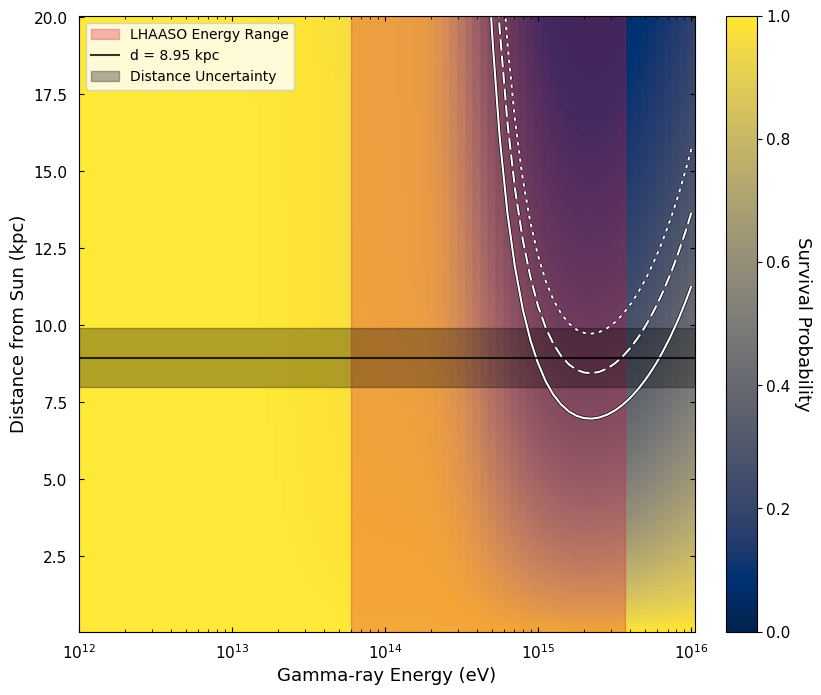

In [13]:
# 2D Survival Phase Space (Cygnus X-3)
fig, ax = plt.subplots(figsize=(10, 8))

(X, Y), Z = atlas_r12.get_2d_phase_space(l, b)

im1 = ax.pcolormesh(X, Y, Z, cmap='cividis', shading='auto', norm=Normalize(0, 1.0), rasterized=True, edgecolor='face')

ax.set_box_aspect(1)

cs = ax.contour(X, Y, Z, levels=[0.25, 0.3, 0.37], colors='white', linestyles=[':','--','-'], linewidths=1.5)
plt.setp(cs.collections, path_effects=[path_effects.withStroke(linewidth=2.5, foreground='black', alpha=0.9)])

ax.set_xscale('log')
ax.set_xlabel('Gamma-ray Energy (eV)')
ax.set_ylabel('Distance from Sun (kpc)')

# Shaded region for LHAASO energy range: 60 TeV to 3700 TeV (converted to eV)
energy_min_ev = 60 * 1e12
energy_max_ev = 3700 * 1e12
ax.axvspan(energy_min_ev, energy_max_ev, color='crimson', alpha=0.3, label='LHAASO Energy Range')

# Indicator lines for Cygnus X-3 distance location and its uncertainty bounds
ax.axhline(d, color='black', ls='-', lw=1.5, alpha=0.8, label=f'd = {d} kpc')
ax.axhspan(d - d_err, d + d_err, color='black', alpha=0.30, label='Distance Uncertainty')

cbar = fig.colorbar(im1, ax=ax, fraction=0.05, pad=0.04)
cbar.ax.tick_params(labelsize=11)
cbar.set_label('Survival Probability', rotation=270, labelpad=15)
ax.legend(loc='upper left', fontsize=10)
ax.tick_params(which='both', direction='in', top=True, right=True, pad=8)

## LIV-Corrected Spectral Reconstruction

As evident from the survival probability phase space, Cygnus X-3 lies beyond the traditional Galactic gamma-ray horizon, even when the lower bound of the distance uncertainty is adopted.

The nominal source distance is approximately consistent with the $P_{\rm surv}=0.3$ contour and approaches $P_{\rm surv}\simeq0.25$ when the upper distance estimate is considered.

This places Cygnus X-3 in a regime where Galactic $\gamma\gamma$ attenuation becomes substantial, making it an excellent target for demonstrating the capabilities of the GPSP-LIV atlas framework.

More generally, survival probability phase-space maps can be used to identify Galactic gamma-ray sources that may be particularly sensitive to Lorentz-Invariance Violation (LIV) induced transparency effects.

The figure below compares intrinsic spectra reconstructed under:

- Standard Lorentz-Invariant (LI) attenuation using the GPSP R12 atlas.
- A range of subluminal LIV scenarios characterized by different values of $\log_{10}(\lambda/E_{\rm Pl})$ using the GPSP-LIV R12 atlas.

The observed LHAASO flux points and their corresponding LI-corrected counterparts are also shown.

For reference, the intrinsic photohadronic spectral templates proposed by Cao et al. (2025) are overlaid:

- $pp+p\gamma_{\rm UV}$ scenario (solid black curve).
- $p\gamma_{\rm X}+p\gamma_{\rm UV}$ scenario (purple dashed curve).

The comparison illustrates how increasing LIV-induced transparency progressively modifies the reconstructed intrinsic spectrum, particularly at the highest observed energies.

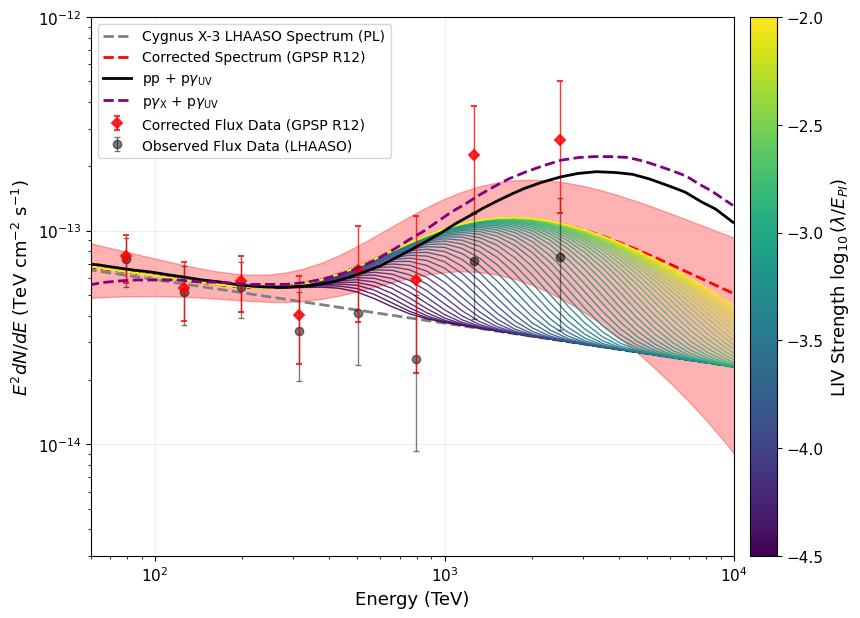

In [42]:
from gpsp_liv_atlas_helper import GPSPLIVAtlasHelper

atlas_liv = GPSPLIVAtlasHelper("GPSP_Atlas_LIV_R12.fits")

# ============================================================
# Continuous LIV Scan Calculations
# ============================================================
all_lambdas = atlas_liv.lam_axis
all_liv_seds = []

# We will just plot the corrected models without errors, so we can use only l,b,d values. 
region_kwargs_fast = dict(l=l, b=b, d=d, random_seed=1, return_individual=True)

for lam in all_lambdas:
    #print(lam)
    res = atlas_liv.get_region_survival_profile(lambda_=lam, **region_kwargs_fast)
    
    # Calculation for continuous map lines (ax1)
    corr = atlas_liv.process_spectrum_with_gpsp_liv(gpsp_result=res, mode="correct", energy=energy_model, flux=flux_observed_model, 
                                                    calc_errors=False, return_table=False)
    all_liv_seds.append((energy_model**2 * corr["flux"]).to("TeV cm-2 s-1").value)

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(energy_model, sed_observed_model, lw=2, color='gray', ls='--', label='Cygnus X-3 LHAASO Spectrum (PL)')
ax.plot(energy_model, sed_corrected_model, lw=2.0, ls='--', color='red', label='Corrected Spectrum (GPSP R12)')
ax.fill_between(energy_model.value, sed_model_total_low.value, sed_model_total_high.value, alpha=0.30, color='red')
ax.errorbar(energy_flux.value, sed_corrected_data.value, yerr=[sed_corrected_errn.value, sed_corrected_errp.value], fmt='D', markersize=5, 
            markerfacecolor='red', markeredgecolor='red', markeredgewidth=1.5, ecolor='red', elinewidth=1, capsize=2, linestyle='none', 
            zorder=10, label='Corrected Flux Data (GPSP R12)', alpha=0.8)
ax.errorbar(energy_flux.value, sed_observed_data.value, yerr=[sed_observed_errn.value, sed_observed_errp.value], fmt='o', markersize=6, 
            markerfacecolor='black', markeredgecolor='black', ecolor='black', elinewidth=1, capsize=2, linestyle='none', 
            zorder=8, label='Observed Flux Data (LHAASO)', alpha=0.5)

# Sequential continuous line tracking matching the FITS axis parameters
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=np.min(all_lambdas), vmax=np.max(all_lambdas))

for lam, sed_val in zip(all_lambdas, all_liv_seds):
    ax.plot(energy_model.value, sed_val, color=cmap(norm(lam)), alpha=0.9, lw=1)

# ============================================================================================================
# PP & PG Theoretical Models (Plotting photohadronic model templates given in the LHAASO paper for comparison)
# ============================================================================================================
ERG_TO_TEV = 0.624150907

energy_pp = np.array([31.42476863381359, 35.4539066290759, 39.999641999295434, 45.548948892247594, 54.331452357827835, 63.6156608759424, 73.11667129005818, 84.82012201954275, 96.58754953282858, 109.98751832268238, 127.59271668354947, 145.2941536662851, 165.45138028496757, 190.1615737416198, 216.54336625893941, 244.3076272030047, 278.2012945956915, 325.7404868924516, 367.5055339330258, 414.6255160353791, 467.78673095029285, 527.7643376932517, 600.9829642596379, 678.0384203140605, 764.9735961955994, 871.1011081790749, 982.7899532080535, 1098.5570177089373, 1216.6180347579736, 1359.9287168045428, 1520.1205817712244, 1683.4866875154337, 1881.7918404159136, 2162.837790843992, 2509.034106272588, 2883.758802123114, 3345.349900681743, 3917.0051564906094, 4460.425234977214, 5079.239055094615, 5947.182256122042, 6772.25603552228, 7711.800004400428, 8620.20616546578, 9907.635509470103])
sed_pp = ERG_TO_TEV * np.array([1.1624085942472336e-13, 1.1624085942472336e-13, 1.1624085942472336e-13, 1.1513434577159468e-13, 1.1295278142514113e-13, 1.1081255333648122e-13, 1.076780245614327e-13, 1.0463216146861719e-13, 1.0264962508440145e-13, 9.974599915135369e-14, 9.692450740586031e-14, 9.41828265373711e-14, 9.239825135222387e-14, 8.978460362994543e-14, 8.808336592518506e-14, 8.724488754940478e-14, 8.724488754940478e-14, 8.808336592518506e-14, 8.978460362994543e-14, 9.239825135222387e-14, 9.692450740586031e-14, 1.0264962508440145e-13, 1.0975771251878862e-13, 1.1962465403079257e-13, 1.303786086971997e-13, 1.4346500363050465e-13, 1.5786488439591912e-13, 1.7371013879730236e-13, 1.8752398822233837e-13, 2.0438192176911203e-13, 2.206349005201517e-13, 2.359130095506042e-13, 2.5224910839207654e-13, 2.6971642134448944e-13, 2.8564797770067704e-13, 2.9678841945936007e-13, 3.025205760841347e-13, 2.9964079099806393e-13, 2.939632473138037e-13, 2.8023552288876024e-13, 2.5959213025708294e-13, 2.4278048431954263e-13, 2.1853461000699357e-13, 2.0243638051959422e-13, 1.7537963067569949e-13])

energy_pg = np.array([30.56198900950994, 34.162017419843316, 37.833381268981455, 42.28993831390829, 49.51648184413954, 56.386097177628386, 65.41156152800055, 75.88169062406753, 86.40905456488527, 101.17471323253822, 119.5679612056647, 139.99980106661292, 173.30899131097718, 212.5615251260181, 244.3076272030047, 283.41274270416903, 325.7404868924516, 381.403438531093, 430.3050844281305, 480.99257497628014, 537.6507635037088, 595.4320157285391, 671.7753379100525, 750.9066503742032, 847.1846779388683, 946.9782125949416, 1048.7491804190786, 1183.2152987448255, 1322.5913285476297, 1478.38506162405, 1667.9372484948092, 1917.0439770870737, 2203.354840478733, 2532.426282905541, 2910.644604551004, 3283.8329332458297, 3774.273973508348, 4297.895102140114, 4848.949768025979, 5420.1284606084855, 6115.074066795924, 6835.394997639405, 7569.98926297504, 8383.534948454562, 9198.744982654389, 9907.635509470103])
sed_pg = ERG_TO_TEV * np.array([6.485855182766183e-14, 7.001624923442474e-14, 7.48646141897172e-14, 7.928670244857137e-14, 8.477701182354647e-14, 8.808337994946764e-14, 9.151868438303644e-14, 9.328627165592435e-14, 9.418281154195909e-14, 9.418281154195909e-14, 9.418281154195909e-14, 9.239825135222387e-14, 9.151868438303644e-14, 8.978460362994543e-14, 8.978460362994543e-14, 8.978460362994543e-14, 9.151868438303644e-14, 9.508798288107927e-14, 9.974598327019567e-14, 1.0463217812773304e-13, 1.1187754965218606e-13, 1.1962465403079257e-13, 1.3163165028615772e-13, 1.4484379276765955e-13, 1.5938209084228907e-13, 1.770651395003929e-13, 1.9483756679944757e-13, 2.1439385269987015e-13, 2.359130095506042e-13, 2.571209940624743e-13, 2.8023554519775053e-13, 3.0252055200107655e-13, 3.234689755258347e-13, 3.4257557714608123e-13, 3.5254802053522203e-13, 3.5593625762352165e-13, 3.5593625762352165e-13, 3.5254802053522203e-13, 3.393144963604801e-13, 3.234689755258347e-13, 3.054280138689376e-13, 2.883932578210234e-13, 2.646058374912102e-13, 2.45113796868891e-13, 2.2489619609850122e-13, 2.1033152028277622e-13])

interp_pp = interp1d(energy_pp, sed_pp, kind='linear', bounds_error=False, fill_value='extrapolate')
interp_pg = interp1d(energy_pg, sed_pg, kind='linear', bounds_error=False, fill_value='extrapolate')

energy_tev = energy_flux.to("TeV").value
model_pp_interp = interp_pp(energy_tev)
model_pg_interp = interp_pg(energy_tev)

ax.plot(energy_pp, sed_pp, lw=2, ls='-', color='black', label='pp + p$\gamma_{\\text{UV}}$', zorder=100)
ax.plot(energy_pg, sed_pg, lw=2, ls='--', color='purple', label='p$\gamma_{\\text{X}}$ + p$\gamma_{\\text{UV}}$', zorder=100)

# Colorbar configuration mapping directly to axis components
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"LIV Strength $\log_{10}(\lambda/E_{Pl})$")

# Axis formatting
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy (TeV)")
ax.set_ylabel(r"$E^2 dN/dE$ (TeV cm$^{-2}$ s$^{-1}$)")
ax.set_xlim(60, 10000)
ax.set_ylim(3e-15, 1e-12)
ax.grid(alpha=0.2)
ax.legend(loc='upper left')

## Statistical LIV Compatibility Test

The GPSP-LIV atlas can be used to construct simple statistical tests that quantify the compatibility of different LIV scenarios with physically motivated intrinsic emission models.

In this example, the reconstructed LIV-corrected flux points are compared with the intrinsic photohadronic spectral templates discussed above.

The analysis procedure is summarized below.

### Step 1: Construct LIV-Corrected Flux Points

For each tested value of

$$
\log_{10}\left(\lambda/E_{\rm Pl}\right),
$$

a survival probability profile is extracted from the GPSP-LIV atlas using the same source morphology and distance-sampling configuration adopted throughout this tutorial.

The resulting survival probabilities are then used to correct the observed LHAASO flux points.

Repeating this procedure across the full atlas range

$$
\log_{10}\left(\lambda/E_{\rm Pl}\right)\in[-4.5,-2.0]
$$

produces a family of LIV-corrected intrinsic flux-point datasets.

### Step 2: Account for Asymmetric Uncertainties

Because the reconstructed flux points possess asymmetric uncertainties, a split-normal $\chi^2$ statistic is adopted.

For each data point, the upper or lower uncertainty is selected depending on whether the tested model lies above or below the measured flux value.

### Step 3: Compare with Physical Models

For every tested LIV strength, the split-normal statistic is evaluated against:

- The $pp+p\gamma_{\rm UV}$ intrinsic spectral model.
- The $p\gamma_{\rm X}+p\gamma_{\rm UV}$ intrinsic spectral model.

This produces a test-statistic profile as a function of LIV strength.

### Step 4: Construct Relative Test Statistics

To facilitate interpretation, the results are expressed as

$$
\Delta\chi^2
=
\chi^2_{\rm split}
-
\chi^2_{\rm split,min},
$$

where $\chi^2_{\rm split,min}$ denotes the minimum value obtained over the tested LIV parameter range.

In this representation, the preferred LIV solution is located at $\Delta\chi^2=0$, while increasingly disfavored scenarios appear at larger values of $\Delta\chi^2$.

Reference levels corresponding approximately to the 1$\sigma$, 2$\sigma$, and 3$\sigma$ confidence intervals are indicated in the figure below.

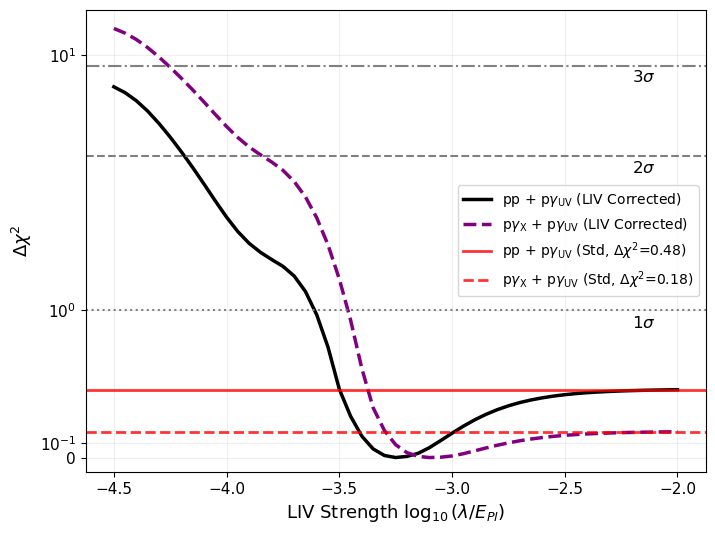

In [48]:
# Dynamically select the error based on the model's position relative to the data
# Define Chisqr-split test
def compute_chi2_split(data, model, errp, errn):
    error = np.where(model > data, errp, errn)
    return np.sum(((data - model) / error)**2)

chi2_values_pp_asym = []
chi2_values_pg_asym = []

chi2_pp_std_asym = compute_chi2_split(sed_corrected_data.value, model_pp_interp, sed_corrected_errp.value, sed_corrected_errn.value)
chi2_pg_std_asym = compute_chi2_split(sed_corrected_data.value, model_pg_interp, sed_corrected_errp.value, sed_corrected_errn.value)

for lam in all_lambdas:

    res = atlas_liv.get_region_survival_profile(lambda_=lam, **region_kwargs)
    # Calculation for chi-square profiles (ax)
    liv_corrected = atlas_liv.process_spectrum_with_gpsp_liv(
        gpsp_result=res, mode="correct", energy=energy_flux,
        flux=flux_observed_data, flux_errp=flux_observed_errp, flux_errn=flux_observed_errn,
        calc_errors=True, return_table=True, error_comb_mode='quadrature'
    )
    sed_corr = (energy_flux**2 * liv_corrected["flux"]).to("TeV cm-2 s-1").value
    sed_corr_errp = (energy_flux**2 * liv_corrected["flux_errp"]).to("TeV cm-2 s-1").value
    sed_corr_errn = (energy_flux**2 * liv_corrected["flux_errn"]).to("TeV cm-2 s-1").value

    chi2_values_pp_asym.append(compute_chi2_split(sed_corr, model_pp_interp, sed_corr_errp, sed_corr_errn))
    chi2_values_pg_asym.append(compute_chi2_split(sed_corr, model_pg_interp, sed_corr_errp, sed_corr_errn))

chi2_values_pp_asym = np.array(chi2_values_pp_asym)
chi2_values_pg_asym = np.array(chi2_values_pg_asym)

delta_chi2_pp_asym = chi2_values_pp_asym - np.min(chi2_values_pp_asym)
delta_chi2_pg_asym = chi2_values_pg_asym - np.min(chi2_values_pg_asym)

delta_chi2_pp_std_asym = chi2_pp_std_asym - np.min(chi2_values_pp_asym)
delta_chi2_pg_std_asym = chi2_pg_std_asym - np.min(chi2_values_pg_asym)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(all_lambdas, delta_chi2_pp_asym, lw=2.5, ls='-', color='black', label='pp + p$\gamma_{\\text{UV}}$ (LIV Corrected)')
ax.plot(all_lambdas, delta_chi2_pg_asym, lw=2.5, ls='--', color='purple', label='p$\gamma_{\\text{X}}$ + p$\gamma_{\\text{UV}}$ (LIV Corrected)')

# Reference levels tracking baseline GPSP profiles
ax.axhline(delta_chi2_pp_std_asym, color='red', lw=2.0, alpha=0.8, 
            label=f'pp + p$\gamma_{{\\text{{UV}}}}$ (Std, $\Delta\chi^2$={delta_chi2_pp_std_asym:.2f})')

ax.axhline(delta_chi2_pg_std_asym, color='red', lw=2.0, ls='--', alpha=0.8, 
            label=f'p$\gamma_{{\\text{{X}}}}$ + p$\gamma_{{\\text{{UV}}}}$ (Std, $\Delta\chi^2$={delta_chi2_pg_std_asym:.2f})')

# Statistical boundary reference levels
ax.axhline(1.0, color='gray', ls=':', lw=1.5)
ax.axhline(4.0, color='gray', ls='--', lw=1.5)
ax.axhline(9.0, color='gray', ls='-.', lw=1.5)

ax.text(-2.2, 0.85, r'1$\sigma$')
ax.text(-2.2, 3.45, r'2$\sigma$')
ax.text(-2.2, 7.8, r'3$\sigma$')

# Formatting configuration for symlog layout parameters
ax.set_xlabel(r"LIV Strength $\log_{10}(\lambda/E_{Pl})$")
ax.set_ylabel(r"$\Delta \chi^2$")
ax.set_yscale('symlog', linthresh=0.5, linscale=0.25)
#ax2.set_yscale('log')
ax.set_ylim(-0.1, 15)
ax.grid(alpha=0.2)
ax.legend()

## Interpretation of the Test Statistic Profiles

The resulting $\Delta\chi^2$ profiles provide a quantitative measure of how well different LIV-induced transparency scenarios reproduce the intrinsic photohadronic spectral templates.

The horizontal red lines indicate the corresponding standard Lorentz-Invariant reconstruction obtained using the GPSP R12 atlas.

This example is intended as a demonstration of the GPSP-LIV analysis workflow.